## Prerequisite

In [1]:
%reload_ext autoreload
%autoreload 2

import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings
import pyEPR as epr

# 1. Create the Qbit design

In [2]:
design = designs.DesignPlanar({}, True)

design.overwrite_enabled=True

design.chips.main.size['size_x'] = '2mm'
design.chips.main.size['size_y'] = '2mm'

gui = MetalGUI(design)

In [3]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design.delete_all_components()

q1 = TransmonPocket(design, 'Q1', options = dict(
    pad_width = '425 um', 
    pocket_height = '650um',
    connection_pads=dict(
        readout = dict(loc_W=+1,loc_H=+1, pad_width='200um')
    )))

gui.rebuild()
gui.autoscale()

# 2. Analyze the transmon using the Eigenmode method

In [4]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_qb = EPRanalysis(design, "hfss")

hfss = eig_qb.sim.renderer
hfss.start()

INFO 07:29AM [connect_project]: Connecting to Ansys Desktop API...
INFO 07:29AM [load_ansys_project]: 	Opened Ansys App
INFO 07:29AM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 07:29AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project15
INFO 07:29AM [connect_design]: No active design found (or error getting active design).
INFO 07:29AM [connect]: 	 Connected to project "Project15". No design detected


True

In [5]:
hfss.activate_ansys_design("TransmonQubit", 'eigenmode')  # use new_ansys_design() to force creation of a blank design

07:29AM 55s WARNING [activate_ansys_design]: The design_name=TransmonQubit was not in active project.  Designs in active project are: 
[].  A new design will be added to the project.  
INFO 07:29AM [connect_design]: 	Opened active design
	Design:    TransmonQubit [Solution type: Eigenmode]
WARNING 07:29AM [connect_setup]: 	No design setup detected.
WARNING 07:29AM [connect_setup]: 	Creating eigenmode default setup.
INFO 07:29AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


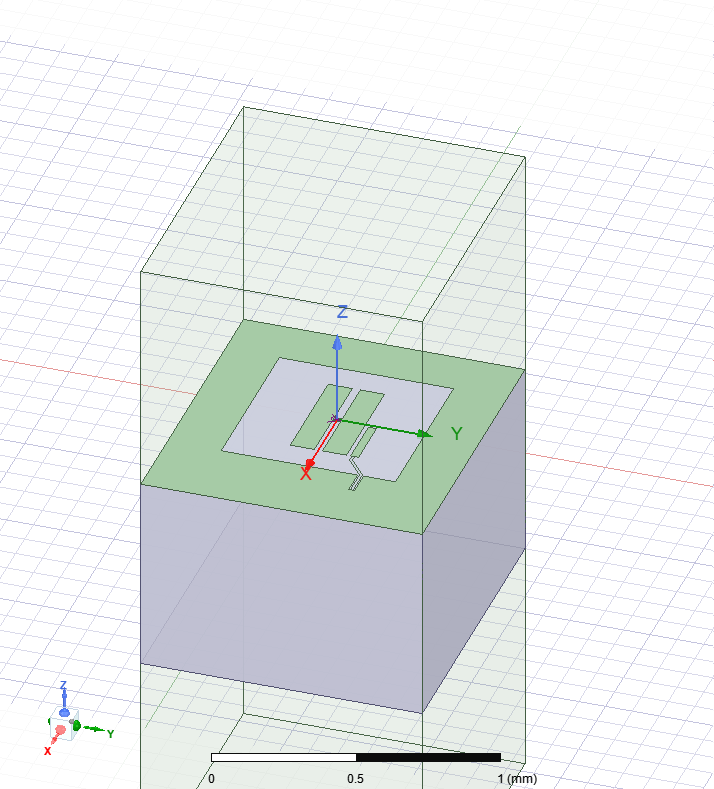

WindowsPath('c:/Users/giann/Projects/qiskit-metal-simulations/ansys.png')

In [6]:
hfss.render_design(['Q1'], [])
hfss.save_screenshot()

In [7]:
# Analysis properties
setup = hfss.pinfo.setup
setup.passes = 10
print(f"""
Number of eigenmodes to find             = {setup.n_modes}
Number of simulation passes              = {setup.passes}
Convergence freq max delta percent diff  = {setup.delta_f}
""")

pinfo = hfss.pinfo
pinfo.design.set_variable('Lj', '10 nH')
pinfo.design.set_variable('Cj', '0 fF')

setup.analyze()

INFO 07:31AM [analyze]: Analyzing setup Setup



Number of eigenmodes to find             = 1
Number of simulation passes              = 10
Convergence freq max delta percent diff  = 0.1



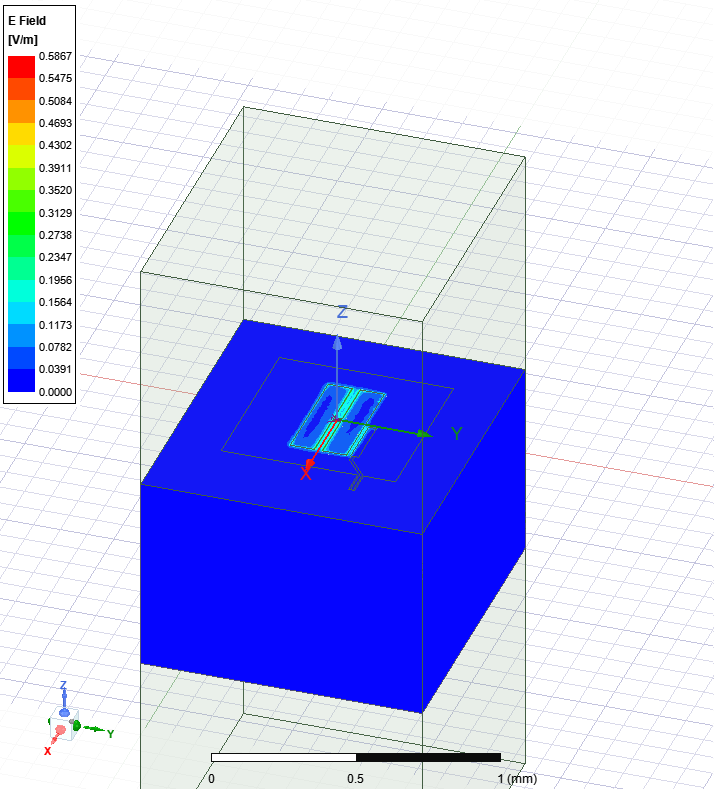

WindowsPath('c:/Users/giann/Projects/qiskit-metal-simulations/ansys.png')

In [8]:
hfss.modeler._modeler.ShowWindow()
hfss.plot_fields('main')
hfss.save_screenshot()

In [9]:
hfss.plot_ansys_delete(['Mag_E1'])

07:46AM 01s WARNING [plot_ansys_delete]: This method is deprecated. Change your scripts to use clear_fields()


# 3. Analyze the transmon using the EPR method

In [10]:
pinfo = hfss.pinfo
pinfo.junctions['jj'] = {'Lj_variable': 'Lj', 'rect': 'JJ_rect_Lj_Q1_rect_jj', 
                             'line': 'JJ_Lj_Q1_rect_jj_',  'Cj_variable': 'Cj'}
pinfo.validate_junction_info() # Check that valid names of variables and objects have been supplied
pinfo.dissipative['dielectrics_bulk'] = ['main'] # Dissipative elements: specify

In [14]:
eprd = epr.DistributedAnalysis(pinfo)

Design "TransmonQubit" info:
	# eigenmodes    1
	# variations    1


In [15]:
eprd.do_EPR_analysis()

# 4a. Perform Hamiltonian spectrum post-analysis, building on mw solutions using EPR
epra = epr.QuantumAnalysis(eprd.data_filename)
result = epra.analyze_all_variations(cos_trunc = 8, fock_trunc = 7)

  options=pd.Series(get_instance_vars(self.options)),




Variation 0  [1/1]


  Ljs = pd.Series({})

  Cjs = pd.Series({})

  _Om = pd.Series({})




  Mode 0 at 6.37 GHz   [1/1]
    Calculating ℰ_magnetic,ℰ_electric


  Sj = pd.Series({})



...

  sol = sol.append(self.get_Qdielectric(



p_dielectric_main_0 = 0.9210847360620477


  options=pd.Series(get_instance_vars(self.options)),

WARNING 07:47AM [__init__]: <p>Error: <class 'IndexError'></p>



ANALYSIS DONE. Data saved to:

C:\data-pyEPR\Project15\TransmonQubit\2025-07-30 07-47-05.npz


	 Differences in variations:



 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Variation 0



AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [ ]:
print(type(result))
list(result.items())[0]

# 4. Create the  Duffing Hamiltonian

In [ ]:
f_01 = result['0']['f_0'][0]            # in Hz
alpha = result['0']['chi_O1'][0][0] * 1e6     # in Hz
f_01, alpha

In [ ]:
from qutip import destroy, qeye
import numpy as np

w_q = 2 * np.pi * f_01
alpha_rad = 2 * np.pi * alpha

N = 5
a = destroy(N)

H = w_q * (a.dag() * a) + (alpha_rad / 2) * ((a.dag() * a.dag()) * (a * a))
H

# 5. Estimate the T1, T2 Relaxation times

In [ ]:
import matplotlib.pyplot as plt
from qutip import *

tlist = np.linspace(0, 40e-6, 1000)  # seconds

opts = Options(nsteps=10000)

T1 = 25e-6  # seconds
gamma1 = 1 / T1
c_ops_T1 = [np.sqrt(gamma1) * a]

# Prepare the Initial State
psi_T1 = basis(N, 1)
result_T1 = mesolve(H, psi_T1, tlist, c_ops_T1, [a.dag()*a], options=opts)

# Collapse operators for T2 (T_phi included)
T_phi = 40e-6  # seconds
gamma_phi = 1 / T_phi
c_ops_T2 = [np.sqrt(gamma1) * a, np.sqrt(gamma_phi) * a.dag() * a]

# Initial state for T2 simulation: superposition (|0> + |1>)/sqrt(2)
psi_T2 = (basis(N, 0) + basis(N, 1)).unit()
result_T2 = mesolve(H, psi_T2, tlist, c_ops_T2, [a.dag()*a], options=opts)

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tlist * 1e6, result_T1.expect[0])
plt.xlabel("Time (μs)")
plt.ylabel("Population in |1⟩")
plt.title("T₁ Relaxation")

plt.subplot(1, 2, 2)
plt.plot(tlist * 1e6, result_T2.expect[0].real)
plt.xlabel("Time (μs)")
plt.ylabel("Coherence ⟨1|ρ|1⟩")
plt.title("T₂ Dephasing")

plt.tight_layout()
plt.grid(True)
plt.show()